In [1]:
import sys, os
# os.environ['PATH']='/projects/bdne/spandey3/tex/texlive/bin/x86_64-linux:'+ os.environ['PATH']
# os.environ['PYTHONPATH']='/projects/bdne/spandey3/tex/texlive/bin/x86_64-linux:'
# os.environ['XLA_PYTHON_CLIENT_MEM_FRACTION']='.98'
os.environ['XLA_PYTHON_CLIENT_PREALLOCATE'] = 'false'
import jax_cosmo.background as bkgrd
# os.environ["CUDA_VISIBLE_DEVICES"] = "0"
from jax.lib import xla_bridge
platform = xla_bridge.get_backend().platform
import jax
print(jax.local_device_count(), jax.device_count())
jax.config.update('jax_platform_name', platform)
jax.config.update("jax_enable_x64", True)
import jax
# Change the current working directory to the desired path
# os.chdir('/mnt/home/spandey/ceph/GODMAX/src/')

import matplotlib

import matplotlib.pyplot as pl
# set latex to false:
pl.rcParams['text.usetex'] = False
%load_ext autoreload
%autoreload 2
import pathlib
curr_path = pathlib.Path().absolute()
abs_path_data = os.path.abspath(curr_path / "../../data/") 
abs_path_src = os.path.abspath(curr_path / "../../src/") 
abs_path_results = os.path.abspath(curr_path / "../../results/") 
sys.path.append((curr_path))
sys.path.append((abs_path_data))
sys.path.append((abs_path_results))
sys.path.append(abs_path_src)
import numpyro
numpyro.set_platform("gpu")
numpyro.enable_x64()
from jax import config
config.update("jax_enable_x64", True)
import scipy.interpolate as interp
import pickle as pk
import numpy as np
import jax.numpy as jnp
import colossus 
from jax import vmap, grad, pmap
import matplotlib.pyplot as pl
pl.rc('text', usetex=True)
# Palatino
# pl.rc('font', family='DejaVu Sans')

%matplotlib inline
%load_ext autoreload
%autoreload 2



1 1


/mnt/home/spandey/miniconda3/envs/ili-sbi/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [3]:
from astropy.io import fits
import healpy as hp
import numpy as np
nside = 1024
dfg = fits.open('/mnt/ceph/users/spandey/GODMAX/notebooks/all_arxiv/mock_gen/sdss_data/galaxy_DR12v5_CMASS_North.fits.gz')
ra_g, dec_g, z_g = dfg[1].data['RA'], dfg[1].data['DEC'], dfg[1].data['Z']
indsel = np.where((z_g > 0.4) & (z_g < 0.7))[0]
ra_g, dec_g, z_g = ra_g[indsel], dec_g[indsel], z_g[indsel]
print(len(ra_g))
mapg   = np.zeros((hp.nside2npix(nside)))
pix = hp.ang2pix(nside, ra_g, dec_g, lonlat=True)
weight = 1. #1 for number density, array of size(x) for arbitrary
np.add.at(mapg, pix, weight)  

# df = fits.open('/mnt/ceph/users/spandey/GODMAX/notebooks/all_arxiv/mock_gen/sdss_data/random1_DR12v5_CMASS_South.fits.gz')
df = fits.open('/mnt/ceph/users/spandey/GODMAX/data/sdss/random1_DR12v5_CMASS_North.fits.gz')
ra_rand, dec_rand, z_rand = df[1].data['RA'], df[1].data['DEC'], df[1].data['Z']
mask = np.zeros(12*nside**2)
pix = hp.ang2pix(nside, ra_rand, dec_rand, lonlat=True)
mask[pix] = 1
ind_unmask = np.where(mask == 1)[0]
gal_count_unmask = mapg[ind_unmask]
mean_gal_count = np.mean(gal_count_unmask)
delta_g_data = (mapg / mean_gal_count) - 1


df = hp.read_map('/mnt/home/spandey/ceph/GODMAX/data/NILC_ymap_rotated_celestial_DES_coords.fits')
ymap_data = hp.ud_grade(df, nside_out=nside)


import pymaster as nmt
f_g = nmt.NmtField(mask, [delta_g_data])
f_y = nmt.NmtField(mask, [ymap_data])
b = nmt.NmtBin.from_nside_linear(nside, 64)
cl_gy_data = nmt.compute_full_master(f_g, f_y, b)[0]





579089


In [6]:
import h5py as h5
import healpy as hp
import pickle as pk
import pymaster as nmt

f = h5.File('/mnt/home/spandey/ceph/CHARM/data/pos_ra_dec_z_galaxies_zsel_0.4_0.7.hdf5', 'r')
ra_gal = f['ra'][:]
dec_gal = f['dec'][:]
z_gal = f['z'][:]
vlos_gal = f['v_los'][:]
f.close()

# nside = 1024
sigma_pos_all = [0.0, 2.0, 4.0, 6.0]
cl_gy_mock_all = []
for sigma_pos in sigma_pos_all:
# sigma_pos = 6.0
    print(sigma_pos)
    sdir = '/mnt/home/spandey/ceph/GODMAX/notebooks/all_arxiv/mock_gen/maps_charm/'
    # save_map_fname = sdir + f'tSZ_sim_B12_testv0_nside_{nside}.pkl'
    if sigma_pos == 0.0:
        save_map_fname = sdir + f'tSZ_sim_B12_testv0_nside_{nside}.pkl'
    else:
        save_map_fname = sdir + f'tSZ_sim_B12_testv0_nside_{nside}_sigma_{sigma_pos}.pkl'
    map_test = pk.load(open(save_map_fname, 'rb'))['map_test']

    # ra_rand.shape
    import healpy as hp
    # nside = 1024
    mapg   = np.zeros((hp.nside2npix(nside)))
    pix = hp.ang2pix(nside, ra_gal, dec_gal, lonlat=True)
    weight = 1. #1 for number density, array of size(x) for arbitrary
    np.add.at(mapg, pix, weight)  
    delta_g = mapg / np.mean(mapg) - 1



    f_g = nmt.NmtField(np.ones_like(delta_g), [delta_g])
    f_y = nmt.NmtField(np.ones_like(map_test), [map_test])
    b = nmt.NmtBin.from_nside_linear(nside, 64)
    cl_gy_mock = nmt.compute_full_master(f_g, f_y, b)[0]
    ell_arr = b.get_effective_ells()

    beam_fwhm_arcmin = 10.0
    beam_fwhm = np.radians(beam_fwhm_arcmin / 60.)
    sigma = beam_fwhm / (2. * np.sqrt(2. * np.log(2)))
    beam = np.exp(-0.5 * ell_arr * (ell_arr + 1) * sigma**2)
    cl_gy_mock *= beam

    cl_gy_mock_all.append(cl_gy_mock)




0.0
2.0
4.0
6.0


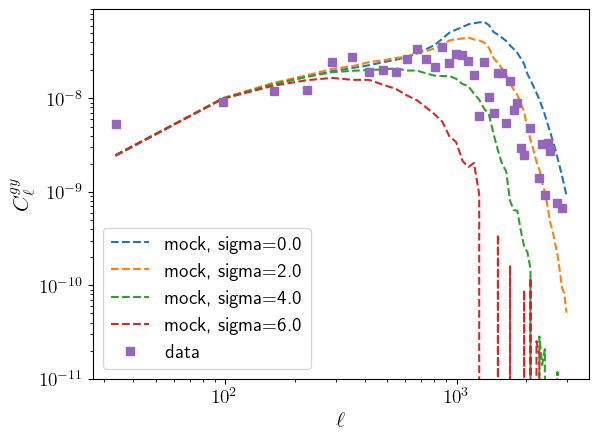

In [15]:
ell_arr = b.get_effective_ells()
fac = ell_arr * (ell_arr + 1) / (2 * np.pi)
pl.figure()
for i, sigma_pos in enumerate(sigma_pos_all):
    pl.plot(ell_arr, fac*cl_gy_mock_all[i], ls='--', label=f'mock, sigma={sigma_pos}')
pl.plot(ell_arr, fac*cl_gy_data, ls='', marker='s', label='data')
pl.xscale('log')
pl.yscale('log')
pl.ylim(1e-11, 9e-8)
pl.xlabel(r'$\ell$', fontsize=16)
pl.ylabel(r'$C_{\ell}^{g y}$', fontsize=16)
# set the tick label sizes:
pl.xticks(fontsize=14)
pl.yticks(fontsize=14)
pl.legend(fontsize=14)



In [16]:
df = fits.open('/mnt/ceph/users/spandey/GODMAX/data/sdss/random1_DR12v5_CMASS_North.fits.gz')
ra_rand, dec_rand, z_rand = df[1].data['RA'], df[1].data['DEC'], df[1].data['Z']
mask_north = np.zeros(12*nside**2)
pix = hp.ang2pix(nside, ra_rand, dec_rand, lonlat=True)
mask_north[pix] = 1

df = fits.open('/mnt/ceph/users/spandey/GODMAX/notebooks/all_arxiv/mock_gen/sdss_data/random1_DR12v5_CMASS_South.fits.gz')
ra_rand, dec_rand, z_rand = df[1].data['RA'], df[1].data['DEC'], df[1].data['Z']
mask_south = np.zeros(12*nside**2)
pix = hp.ang2pix(nside, ra_rand, dec_rand, lonlat=True)
mask_south[pix] = 1

mask_total = mask_north + mask_south


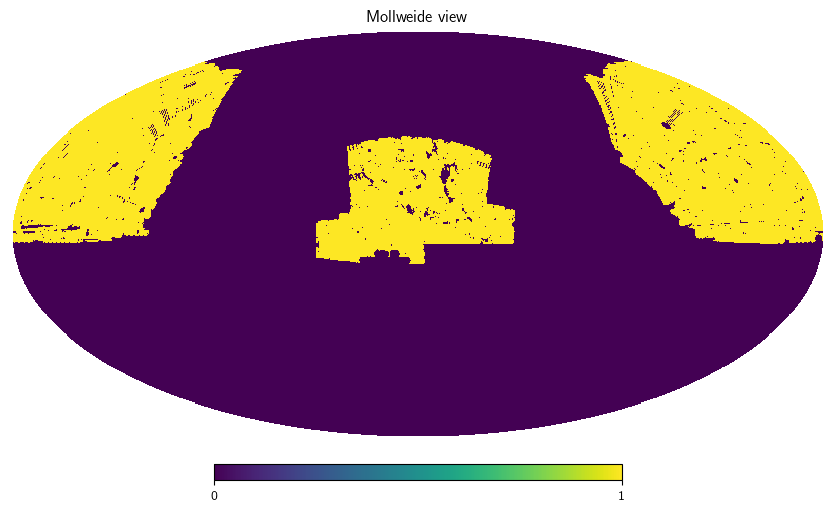

In [17]:
hp.mollview(mask_total)




In [18]:
from astropy.io import fits
import healpy as hp
import numpy as np
nside = 1024
dfg = fits.open('/mnt/ceph/users/spandey/GODMAX/notebooks/all_arxiv/mock_gen/sdss_data/galaxy_DR12v5_CMASS_North.fits.gz')
ra_g, dec_g, z_g = dfg[1].data['RA'], dfg[1].data['DEC'], dfg[1].data['Z']
indsel = np.where((z_g > 0.4) & (z_g < 0.7))[0]
ra_g, dec_g, z_g = ra_g[indsel], dec_g[indsel], z_g[indsel]
print(len(ra_g))
mapg_north   = np.zeros((hp.nside2npix(nside)))
pix = hp.ang2pix(nside, ra_g, dec_g, lonlat=True)
weight = 1. #1 for number density, array of size(x) for arbitrary
np.add.at(mapg_north, pix, weight)  

dfg = fits.open('/mnt/ceph/users/spandey/GODMAX/notebooks/all_arxiv/mock_gen/sdss_data/galaxy_DR12v5_CMASS_South.fits.gz')
ra_g, dec_g, z_g = dfg[1].data['RA'], dfg[1].data['DEC'], dfg[1].data['Z']
indsel = np.where((z_g > 0.4) & (z_g < 0.7))[0]
ra_g, dec_g, z_g = ra_g[indsel], dec_g[indsel], z_g[indsel]
print(len(ra_g))
mapg_south   = np.zeros((hp.nside2npix(nside)))
pix = hp.ang2pix(nside, ra_g, dec_g, lonlat=True)
weight = 1. #1 for number density, array of size(x) for arbitrary
np.add.at(mapg_south, pix, weight)  




579089
213205


In [19]:
mapg = mapg_north + mapg_south
ind_unmask = np.where(mask_total == 1)[0]
gal_count_unmask = mapg[ind_unmask]
mean_gal_count = np.mean(gal_count_unmask)
delta_g_data = (mapg / mean_gal_count) - 1



In [22]:
# np.amin(delta_g_data)


-1.0

/tmp/ipykernel_1400239/1208706164.py:1: RuntimeWarning: divide by zero encountered in log
  hp.mollview(np.log(np.abs(delta_g_data*mask_total)), min=0, max=1, title='SDSS data, galaxy density')


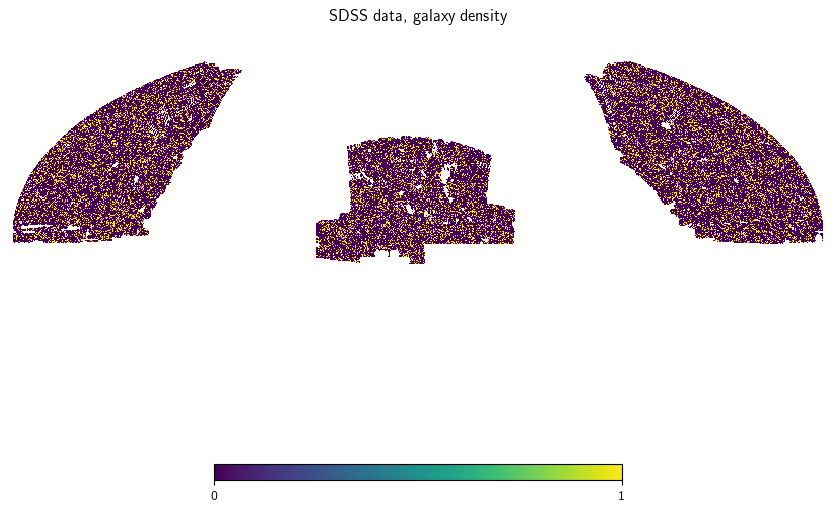

In [40]:
hp.mollview(np.log(np.abs(delta_g_data*mask_total)), min=0, max=1, title='SDSS data, galaxy density')


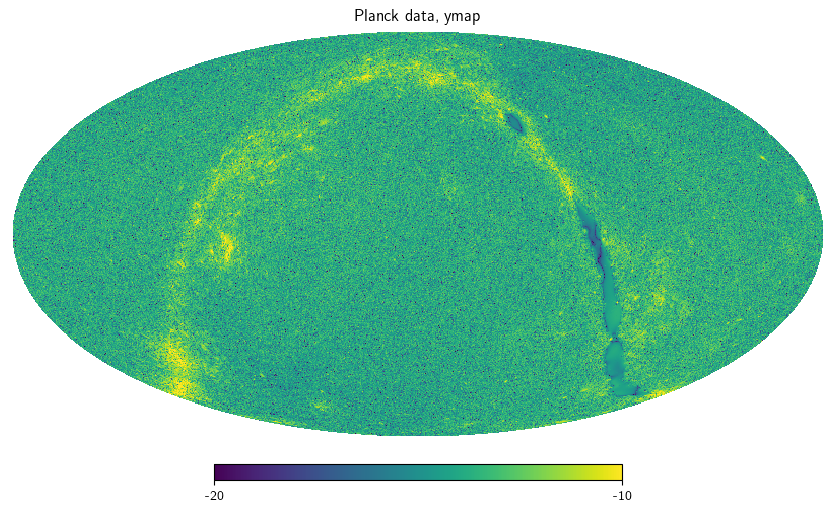

In [29]:
df = hp.read_map('/mnt/home/spandey/ceph/GODMAX/data/NILC_ymap_rotated_celestial_DES_coords.fits')
ymap_data = hp.ud_grade(df, nside_out=nside)
hp.mollview(np.log(np.abs(ymap_data)), min=-20, max=-10, title='Planck data, ymap')


In [30]:
sdir = '/mnt/home/spandey/ceph/GODMAX/notebooks/all_arxiv/mock_gen/maps_charm/'
# save_map_fname = sdir + f'tSZ_sim_B12_testv0_nside_{nside}.pkl'
# if sigma_pos == 0.0:
save_map_fname = sdir + f'tSZ_sim_B12_testv0_nside_{nside}.pkl'
map_test = pk.load(open(save_map_fname, 'rb'))['map_test']

# ra_rand.shape
import healpy as hp
# nside = 1024
mapg   = np.zeros((hp.nside2npix(nside)))
pix = hp.ang2pix(nside, ra_gal, dec_gal, lonlat=True)
weight = 1. #1 for number density, array of size(x) for arbitrary
np.add.at(mapg, pix, weight)  
delta_g = mapg / np.mean(mapg) - 1



/tmp/ipykernel_1400239/1043388099.py:1: RuntimeWarning: divide by zero encountered in log
  hp.mollview(np.log(np.abs(map_test)), min=-20, max=-10, title='mock, tSZ map')


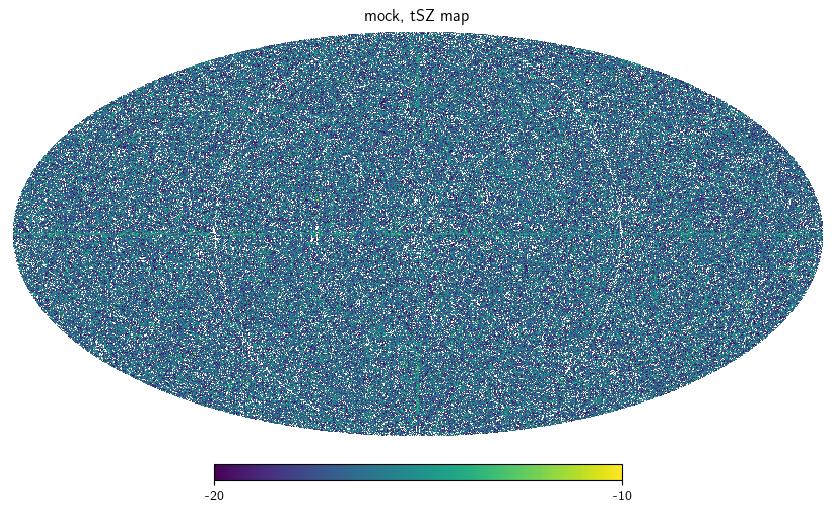

In [33]:
hp.mollview(np.log(np.abs(map_test)), min=-20, max=-10, title='mock, tSZ map')


/tmp/ipykernel_1400239/1522586597.py:1: RuntimeWarning: divide by zero encountered in log
  hp.mollview(np.log(np.abs(delta_g * mask_total)), min=0, max=1, title='mock, galaxy density')


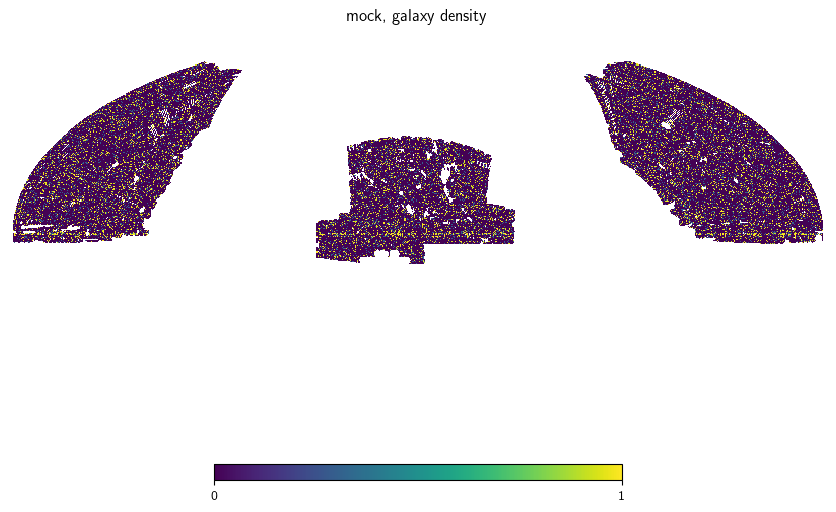

In [41]:
hp.mollview(np.log(np.abs(delta_g * mask_total)), min=0, max=1, title='mock, galaxy density')
